### 📦 IMPORTS

In [14]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, regexp_replace, sum, avg, desc, round,
    substring, max, min, concat, lit,
    count, year, month, to_date
)

import matplotlib.pyplot as plt
import numpy as np
import builtins

### ⚙️ CONFIGURAÇÃO DO SPARK

In [15]:
spark = SparkSession.builder \
    .appName("Bolsa Familia 2025") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "50") \
    .getOrCreate()

### 📂 LEITURA DOS DADOS

In [19]:
caminho_csv = "../dados/NovoBolsaFamilia25.csv"

df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .option("sep", ";") \
    .option("encoding", "ISO-8859-1") \
    .csv(caminho_csv)



In [20]:
print("\n--- DADOS ORIGINAIS ---")
df.show(5)


--- DADOS ORIGINAIS ---
+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
|MÊS COMPETÊNCIA|MÊS REFERÊNCIA| UF|CÓDIGO MUNICÍPIO SIAFI|NOME MUNICÍPIO|CPF FAVORECIDO|NIS FAVORECIDO|     NOME FAVORECIDO|VALOR PARCELA|
+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
|         202501|        202308| SP|                  7071|        SANTOS|***.085.106-**|   20643890445|FERNANDA RAMOS TE...|       650,00|
|         202501|        202309| SP|                  7071|        SANTOS|***.085.106-**|   20643890445|FERNANDA RAMOS TE...|       650,00|
|         202501|        202310| SP|                  7071|        SANTOS|***.085.106-**|   20643890445|FERNANDA RAMOS TE...|       650,00|
|         202501|        202311| SP|                  7071|        SANTOS|***.085.106-**|   20643890445|FERNANDA RAMOS TE...|       650

### 🧹 PADRONIZAÇÃO DE COLUNAS

In [21]:
colunas_padrao = {
    "MÊS COMPETÊNCIA": "data_competencia",
    "MÊS REFERÊNCIA": "data_referencia",
    "CÓDIGO MUNICÍPIO SIAFI": "codigo_municipio",
    "UF": "uf",
    "NOME MUNICÍPIO": "nome_municipio",
    "CPF FAVORECIDO": "cpf_favorecido",
    "NIS FAVORECIDO" : "nis_favorecido",
    "NOME FAVORECIDO": "nome_favorecido",
    "VALOR PARCELA": "valor_parcela"
}

for antiga, nova in colunas_padrao.items():
    df = df.withColumnRenamed(antiga, nova)

###🔄 TRATAMENTO DOS DADOS

In [22]:
df_tratado = (
    df
    .dropna()
    .withColumn(
        "valor_parcela",
        regexp_replace(col("valor_parcela"), ",", ".").cast("decimal(10,2)")
    )
    .withColumn(
        "data_competencia_data",
        to_date(
            concat(
                substring(col("data_competencia"), 1, 4),
                lit("-"),
                substring(col("data_competencia"), 5, 2),
                lit("-01")
            )
        )
    )
    .withColumn("ano_competencia", substring(col("data_competencia"), 1, 4))
    .withColumn("mes_competencia", substring(col("data_competencia"), 5, 2))
)

print("\n--- DADOS TRATADOS ---")
df_tratado.show(5)
df_tratado.printSchema()


--- DADOS TRATADOS ---
+----------------+---------------+---+----------------+--------------+--------------+--------------+--------------------+-------------+---------------------+---------------+---------------+
|data_competencia|data_referencia| uf|codigo_municipio|nome_municipio|cpf_favorecido|nis_favorecido|     nome_favorecido|valor_parcela|data_competencia_data|ano_competencia|mes_competencia|
+----------------+---------------+---+----------------+--------------+--------------+--------------+--------------------+-------------+---------------------+---------------+---------------+
|          202501|         202308| SP|            7071|        SANTOS|***.085.106-**|   20643890445|FERNANDA RAMOS TE...|       650.00|           2025-01-01|           2025|             01|
|          202501|         202309| SP|            7071|        SANTOS|***.085.106-**|   20643890445|FERNANDA RAMOS TE...|       650.00|           2025-01-01|           2025|             01|
|          202501|        

### 📊 RESULTADOS GERAIS

In [23]:
print("\n--- RESULTADOS GERAIS ---")
df_tratado.agg(
    round(sum("valor_parcela"), 2).alias("total_pago"),
    round(avg("valor_parcela"), 2).alias("media_pagamento"),
    round(max("valor_parcela"), 2).alias("valor_maximo"),
    round(min("valor_parcela"), 2).alias("valor_minimo")
).show()


--- RESULTADOS GERAIS ---
+--------------+---------------+------------+------------+
|    total_pago|media_pagamento|valor_maximo|valor_minimo|
+--------------+---------------+------------+------------+
|11118610760.00|         671.27|     3814.00|       25.00|
+--------------+---------------+------------+------------+



### 📊 CAPTURAR RESULTADOS EM VARIÁVEL

In [24]:
resumo = df_tratado.agg(
    round(sum("valor_parcela"), 2).alias("total_pago"),
    round(avg("valor_parcela"), 2).alias("media_pagamento"),
    round(max("valor_parcela"), 2).alias("valor_maximo"),
    round(min("valor_parcela"), 2).alias("valor_minimo")
).toPandas()

resumo_row = resumo.iloc[0]

### 📌 MÉTRICAS FINAIS

In [25]:
amplitude_25 = float(resumo_row['valor_maximo'] - resumo_row['valor_minimo'])

print(f"\nANÁLISE DE EQUIDADE 2025:")
print(f"Amplitude (Maior vs Menor): R$ {amplitude_25:,.2f}".replace(',', '.'))


ANÁLISE DE EQUIDADE 2025:
Amplitude (Maior vs Menor): R$ 3.789.00


### 🏆 RANKING FAVORECIDOS

In [26]:
ranking_favorecido = df_tratado.groupBy("cpf_favorecido", "nome_favorecido") \
    .agg(
        sum("valor_parcela").alias("valor_total_acumulado"),
        count("valor_parcela").alias("quantidade_parcelas")
    ) \
    .orderBy(desc("valor_total_acumulado"))

print("Ranking dos 10 primeiros com valores acumulados")
ranking_favorecido.show(10, truncate=False)

Ranking dos 10 primeiros com valores acumulados
+--------------+-------------------------------+---------------------+-------------------+
|cpf_favorecido|nome_favorecido                |valor_total_acumulado|quantidade_parcelas|
+--------------+-------------------------------+---------------------+-------------------+
|***.431.972-**|ALESSANDRA PANTOJA OLIVEIRA    |13252.00             |7                  |
|***.295.298-**|ERICA CRISTINA RIBEIRO DA SILVA|13130.00             |13                 |
|***.211.052-**|FRANCISCO ARAUJO DE SOUZA      |12090.00             |8                  |
|***.327.042-**|MANOEL MARIA LIMA DA SILVA     |11820.00             |6                  |
|***.444.238-**|PRISCILA LUANA VIANA           |11746.00             |7                  |
|***.432.148-**|MARCELA DA SILVA RAMALHO       |11020.00             |10                 |
|***.190.249-**|TAISA DE SOUZA SANTOS          |10766.00             |6                  |
|***.791.428-**|RAQUEL TARGINO DE MELO OLI

### 📈 MÉDIA GERAL

In [27]:
media_geral = df_tratado.agg(avg("valor_parcela")).collect()[0][0]
print(f"Para fins de comparação, media geral de cada parcela é de: R$ {media_geral:.2f}")

Para fins de comparação, media geral de cada parcela é de: R$ 671.27


### 📊 GRÁFICO 1 - TOP 5 UFs

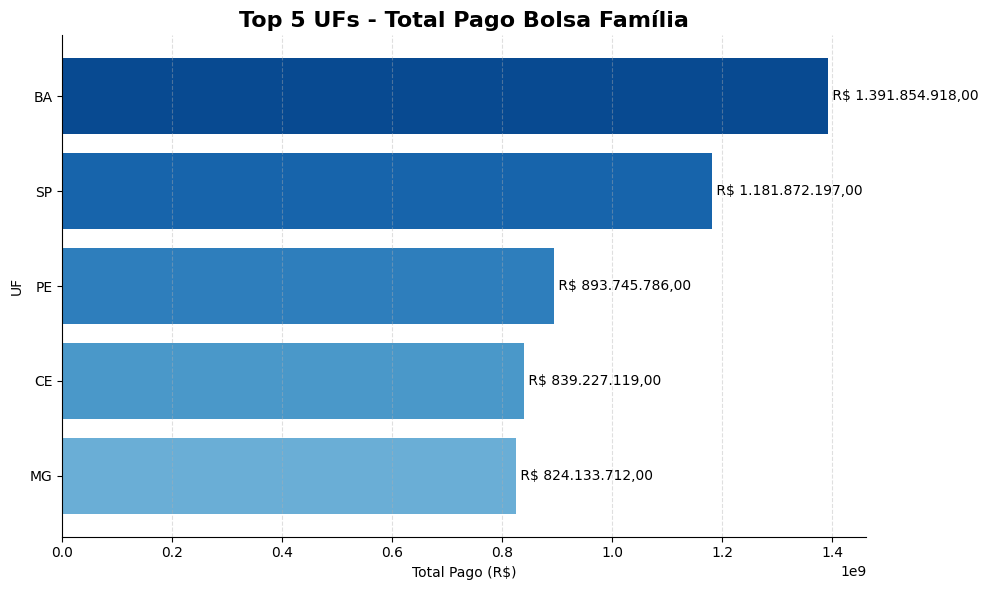

In [28]:
df_uf = df_tratado.groupBy("uf") \
    .agg(sum("valor_parcela").alias("total_pago")) \
    .orderBy("total_pago", ascending=False) \
    .limit(5) \
    .toPandas()

df_uf = df_uf.sort_values(by="total_pago", ascending=True)
colors = plt.cm.Blues(np.linspace(0.5, 0.9, len(df_uf)))

plt.figure(figsize=(10, 6))
bars = plt.barh(df_uf["uf"], df_uf["total_pago"], color=colors)

plt.title("Top 5 UFs - Total Pago Bolsa Família", fontsize=16, fontweight='bold')
plt.xlabel("Total Pago (R$)")
plt.ylabel("UF")
plt.grid(axis='x', linestyle='--', alpha=0.4)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

def formatar_real(valor):
    return f'R$ {valor:,.2f}'.replace(",", "X").replace(".", ",").replace("X", ".")

for bar in bars:
    largura = bar.get_width()
    plt.text(largura, bar.get_y() + bar.get_height()/2,
             f' {formatar_real(largura)}', va='center')

plt.tight_layout()
plt.savefig("top_ufs_bolsa_familia.png", dpi=300, bbox_inches='tight')
plt.show()

### 📈 GRÁFICO 2 - EVOLUÇÃO TEMPORAL

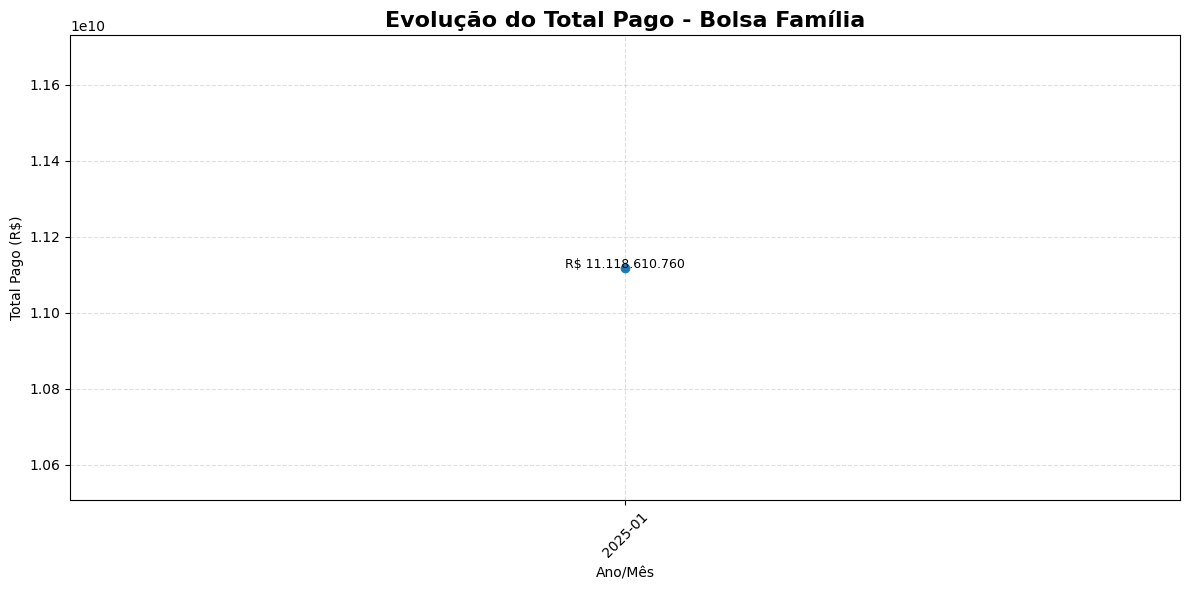

In [29]:
df_tempo = df_tratado.withColumn("ano", year("data_competencia_data")) \
                     .withColumn("mes", month("data_competencia_data"))

df_evolucao = df_tempo.groupBy("ano", "mes") \
    .agg(sum("valor_parcela").alias("total_pago")) \
    .orderBy("ano", "mes") \
    .toPandas()

df_evolucao["data"] = df_evolucao["ano"].astype(str) + "-" + df_evolucao["mes"].astype(str).str.zfill(2)

plt.figure(figsize=(12, 6))
plt.plot(df_evolucao["data"], df_evolucao["total_pago"], marker='o', linewidth=2)

plt.title("Evolução do Total Pago - Bolsa Família", fontsize=16, fontweight='bold')
plt.xlabel("Ano/Mês")
plt.ylabel("Total Pago (R$)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)

def formatar_real(valor):
    return f'R$ {valor:,.0f}'.replace(",", "X").replace(".", ",").replace("X", ".")

step = builtins.max(1, len(df_evolucao)//10)

for i in range(0, len(df_evolucao), step):
    plt.text(df_evolucao["data"][i],
             df_evolucao["total_pago"][i],
             formatar_real(df_evolucao["total_pago"][i]),
             fontsize=9,
             ha='center')

plt.tight_layout()
plt.savefig("evolucao_pagamentos.png", dpi=300, bbox_inches='tight')
plt.show()

### 📊 GRÁFICO 3 - SALTO ORÇAMENTÁRIO

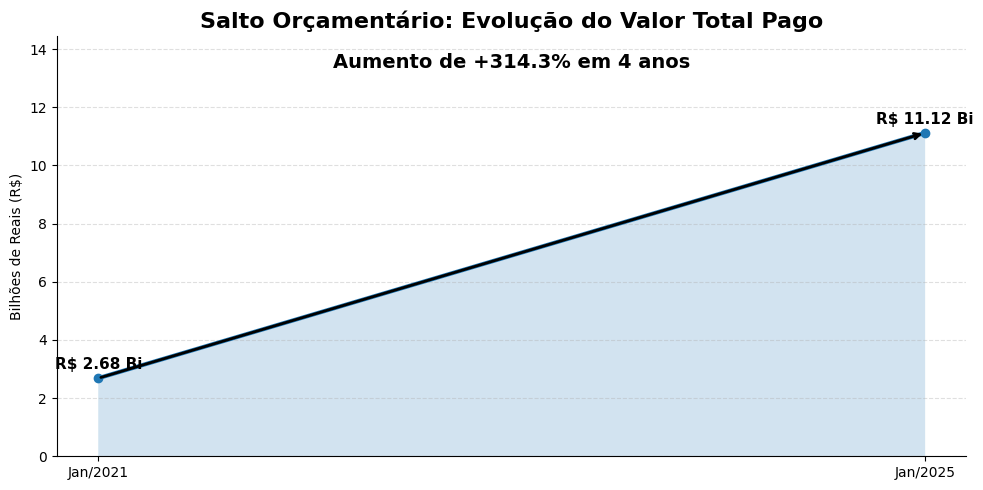

In [ ]:
periodos = ['Jan/2021', 'Jan/2025']

valor_2021 = 2683780840.00 / 1e9
valor_2025 = float(resumo_row['total_pago']) / 1e9

faturamentos_bi = [valor_2021, valor_2025]

crescimento = ((valor_2025 - valor_2021) / valor_2021) * 100

ano_inicio = int(periodos[0].split('/')[1])
ano_fim = int(periodos[1].split('/')[1])
anos = ano_fim - ano_inicio

texto_crescimento = f"Aumento de +{crescimento:.1f}% em {anos} anos"

plt.figure(figsize=(10,5))

# Linha
plt.plot(periodos, faturamentos_bi, marker='o', linewidth=3)

# Área
plt.fill_between(periodos, faturamentos_bi, alpha=0.2)

# Rótulos dos valores
for i, v in enumerate(faturamentos_bi):
    plt.text(
        i,
        v + 0.3,
        f'R$ {v:.2f} Bi',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# 🔥 Texto principal automático
max_valor = builtins.max(faturamentos_bi)

plt.text(
    0.5,
    max_valor * 1.2,
    texto_crescimento,
    ha='center',
    fontsize=14,
    fontweight='bold'
)

# Seta
plt.annotate(
    '',
    xy=(1, valor_2025),
    xytext=(0, valor_2021),
    arrowprops=dict(arrowstyle='->', linewidth=2)
)

# Título
plt.title('Salto Orçamentário: Evolução do Valor Total Pago', fontsize=16, fontweight='bold')
plt.ylabel('Bilhões de Reais (R$)')

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Limpeza visual
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.ylim(0, max_valor * 1.3)

plt.tight_layout()
plt.savefig("salto_orcamentario.png", dpi=300, bbox_inches='tight')

plt.show()